In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Set this to the path where your dataset folders are located
DATA_DIR = r"C:\Users\HP\Downloads\MobileNetV3_Tomato_Training_Folder\MobileNetV3_Tomato_Training_Folder\deployment_bundle\sample_test_images"  # <--- REPLACE THIS WITH YOUR ACTUAL DATA PATH

print("Data root:", DATA_DIR)
if os.path.exists(DATA_DIR):
    print("Classes found:", os.listdir(DATA_DIR))
else:
    print(f"Directory {DATA_DIR} not found. Please update the DATA_DIR path.")

IMG_SIZE = (224, 224)   # MobileNetV3 default input size
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Data root: C:\Users\HP\Downloads\MobileNetV3_Tomato_Training_Folder\MobileNetV3_Tomato_Training_Folder\deployment_bundle\sample_test_images
Classes found: ['Bacterial_spot', 'Early_blight', 'healthy', 'Late_blight', 'Leaf_Mold', 'powdery_mildew', 'Septoria_leaf_spot', 'Spider_mites Two-spotted_spider_mite', 'Target_Spot', 'Tomato_mosaic_virus', 'Tomato_Yellow_Leaf_Curl_Virus']
Found 33 files belonging to 11 classes.
Using 27 files for training.
Found 33 files belonging to 11 classes.
Using 6 files for validation.
['Bacterial_spot', 'Early_blight', 'Late_blight', 'Leaf_Mold', 'Septoria_leaf_spot', 'Spider_mites Two-spotted_spider_mite', 'Target_Spot', 'Tomato_Yellow_Leaf_Curl_Virus', 'Tomato_mosaic_virus', 'healthy', 'powdery_mildew']


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.GaussianNoise(0.02),
], name="augmentation")

In [ ]:
base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
    include_preprocessing=True  # handles its own normalization
)
base_model.trainable = False  # freeze for stage 1

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 11)             │        10,571 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,006,923 (11.47 MB)

 Trainable params: 10,571 (41.29 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights from the training set to address the imbalance
# seen in the confusion matrix (e.g. powdery_mildew has far fewer samples)
train_labels = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in train_ds])
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)  # sanity check

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3),
    tf.keras.callbacks.ModelCheckpoint("best_head.keras", save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight_dict,   # <-- added here too
    callbacks=callbacks
)

{0: np.float64(0.8021302130213022), 1: np.float64(0.9457021577644146), 2: np.float64(0.7618979766315189), 3: np.float64(0.8197148551280086), 4: np.float64(0.8483261938759321), 5: np.float64(1.3390934134735788), 6: np.float64(1.3244983898934852), 7: np.float64(1.227502295684114), 8: np.float64(1.073048364439093), 9: np.float64(0.7630940488083345), 10: np.float64(2.3482652613087396)}
Epoch 1/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 101s 575ms/step - accuracy: 0.3905 - loss: 1.7557 - val_accuracy: 0.6265 - val_loss: 1.1560 - learning_rate: 0.0010
Epoch 2/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 89s 528ms/step - accuracy: 0.6368 - loss: 1.0542 - val_accuracy: 0.7088 - val_loss: 0.9153 - learning_rate: 0.0010
Epoch 3/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 90s 534ms/step - accuracy: 0.7036 - loss: 0.8727 - val_accuracy: 0.7597 - val_loss: 0.7862 - learning_rate: 0.0010
Epoch 4/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 90s 535ms/step - accuracy: 0.7288 - loss: 0.7697 - val_accuracy: 0.7829 - val_loss: 0.7167 - learning_rate: 0

In [ ]:
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 90  # unfreeze last ~40 layers

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # much lower LR for fine-tuning
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_epochs = 10
total_epochs = 15 + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1] + 1,
    class_weight=class_weight_dict,   # <-- added here too
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("best_finetuned.keras", save_best_only=True)
    ]
)

Epoch 16/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 112s 619ms/step - accuracy: 0.8655 - loss: 0.3766 - val_accuracy: 0.8653 - val_loss: 0.4330
Epoch 17/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 103s 614ms/step - accuracy: 0.8625 - loss: 0.3716 - val_accuracy: 0.8645 - val_loss: 0.4253
Epoch 18/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 104s 620ms/step - accuracy: 0.8676 - loss: 0.3703 - val_accuracy: 0.8675 - val_loss: 0.4174
Epoch 19/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 103s 616ms/step - accuracy: 0.8734 - loss: 0.3409 - val_accuracy: 0.8698 - val_loss: 0.4054
Epoch 20/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 103s 612ms/step - accuracy: 0.8739 - loss: 0.3340 - val_accuracy: 0.8690 - val_loss: 0.3961
Epoch 21/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 104s 621ms/step - accuracy: 0.8904 - loss: 0.3109 - val_accuracy: 0.8750 - val_loss: 0.3892
Epoch 22/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 99s 591ms/step - accuracy: 0.8854 - loss: 0.3034 - val_accuracy: 0.8765 - val_loss: 0.3820
Epoch 23/25
168/168 ━━━━━━━━━━━━━━━━━━━━ 102s 606ms/step - accuracy: 0

42/42 ━━━━━━━━━━━━━━━━━━━━ 13s 317ms/step - accuracy: 0.8787 - loss: 0.3625
Validation accuracy: 0.8787
                                      precision    recall  f1-score   support

                      Bacterial_spot       0.90      0.76      0.82       126
                        Early_blight       0.86      0.81      0.83       129
                         Late_blight       0.83      0.90      0.86       154
                           Leaf_Mold       0.91      0.88      0.90       146
                  Septoria_leaf_spot       0.83      0.82      0.82       173
Spider_mites Two-spotted_spider_mite       0.84      0.92      0.87        72
                         Target_Spot       0.77      0.91      0.83        90
       Tomato_Yellow_Leaf_Curl_Virus       0.99      0.96      0.98       102
                 Tomato_mosaic_virus       0.95      0.92      0.94       131
                             healthy       0.95      0.95      0.95       168
                      powdery_mildew 

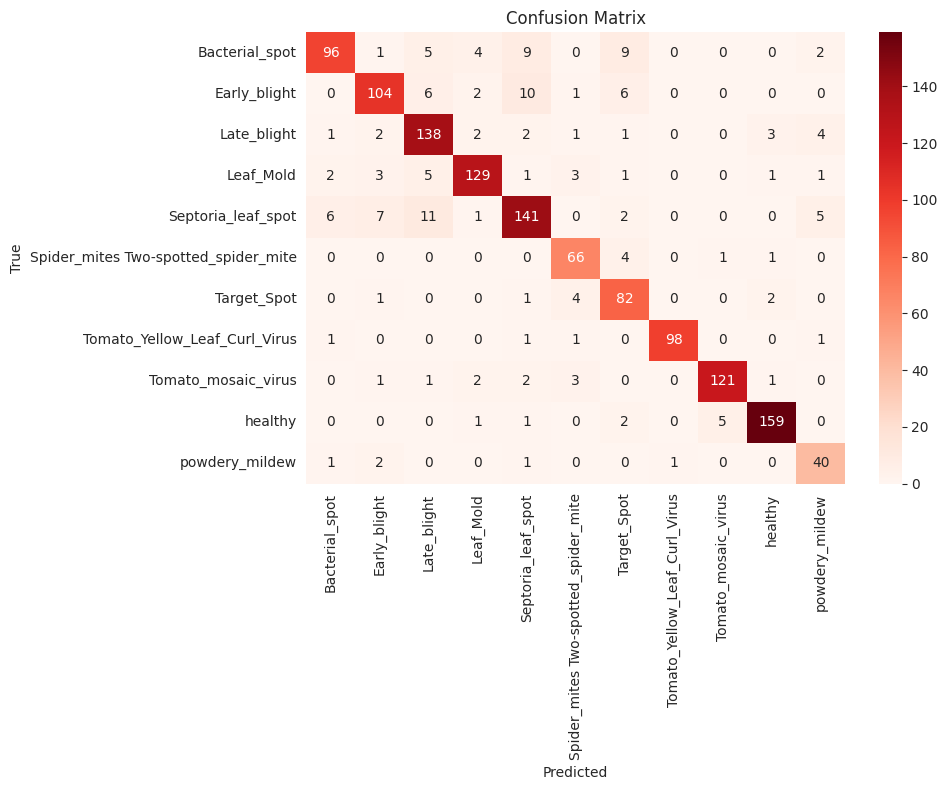

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Force white background regardless of notebook theme
plt.style.use('default')
sns.set_style("white")

loss, acc = model.evaluate(val_ds)
print(f"Validation accuracy: {acc:.4f}")

y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8), facecolor="white")
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Reds",       # light colormap reads better on white than the dark "rocket" default
    cbar=True,
    ax=ax
)
ax.set_facecolor("white")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200, facecolor="white")  # useful for pasting into your report
plt.show()

In [ ]:
model.save("tomato_disease_mobilenetv3.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # quantize for edge inference
tflite_model = converter.convert()

with open("tomato_disease_mobilenetv3.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model size (KB):", len(tflite_model) / 1024)

INFO:tensorflow:Assets written to: /tmp/tmpilkuq1zm/assets


INFO:tensorflow:Assets written to: /tmp/tmpilkuq1zm/assets


Saved artifact at '/tmp/tmpilkuq1zm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_633')
Output Type:
  TensorSpec(shape=(None, 11), dtype=tf.float32, name=None)
Captures:
  132751762260816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132751762273104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132751762267152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132751762263504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132751762263696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132751762275600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132751762275792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132751762260432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132751762260624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132751762263888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132751762

W0000 00:00:1784872840.172684      58 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784872840.172728      58 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


In [ ]:
import tensorflow as tf
import numpy as np

# 1. Load the TFLite model and allocate tensors
interpreter = tf.lite.Interpreter(model_path="tomato_disease_mobilenetv3.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("TFLite input shape:", input_details[0]['shape'])
print("TFLite output shape:", output_details[0]['shape'])

# 2. Grab one real batch from your validation set to test with
for images, labels in val_ds.take(1):
    test_image = images[0:1]          # keep batch dim: shape (1, 224, 224, 3)
    true_label_idx = np.argmax(labels[0].numpy())
    break

test_image_np = test_image.numpy().astype(np.float32)

# 3. Run inference with the Keras model
keras_pred = model.predict(test_image_np, verbose=0)
keras_class_idx = np.argmax(keras_pred[0])

# 4. Run inference with the TFLite interpreter
interpreter.set_tensor(input_details[0]['index'], test_image_np)
interpreter.invoke()
tflite_pred = interpreter.get_tensor(output_details[0]['index'])
tflite_class_idx = np.argmax(tflite_pred[0])

# 5. Compare
print("\nTrue label:      ", class_names[true_label_idx])
print("Keras prediction: ", class_names[keras_class_idx], f"({keras_pred[0][keras_class_idx]:.4f})")
print("TFLite prediction:", class_names[tflite_class_idx], f"({tflite_pred[0][tflite_class_idx]:.4f})")

# 6. Check numerical agreement between the two outputs
max_diff = np.max(np.abs(keras_pred[0] - tflite_pred[0]))
print(f"\nMax difference between Keras and TFLite outputs: {max_diff:.6f}")

TFLite input shape: [  1 224 224   3]
TFLite output shape: [ 1 11]

True label:       Late_blight
Keras prediction:  Late_blight (0.4169)
TFLite prediction: Leaf_Mold (0.4426)

Max difference between Keras and TFLite outputs: 0.153952


In [ ]:
correct_keras = 0
correct_tflite = 0
total = 0

for images, labels in val_ds:  # check 5 batches (~160 images)
    images_np = images.numpy().astype(np.float32)
    true_idxs = np.argmax(labels.numpy(), axis=1)

    keras_preds = model.predict(images_np, verbose=0)
    keras_idxs = np.argmax(keras_preds, axis=1)

    for i in range(images_np.shape[0]):
        interpreter.set_tensor(input_details[0]['index'], images_np[i:i+1])
        interpreter.invoke()
        tflite_out = interpreter.get_tensor(output_details[0]['index'])
        tflite_idx = np.argmax(tflite_out[0])

        correct_keras += int(keras_idxs[i] == true_idxs[i])
        correct_tflite += int(tflite_idx == true_idxs[i])
        total += 1

print(f"Keras accuracy on sample:  {correct_keras/total:.4f}")
print(f"TFLite accuracy on sample: {correct_tflite/total:.4f}")

Keras accuracy on sample:  0.8787
TFLite accuracy on sample: 0.8825
